# Notebook 3A — Baseline Models & Evaluation
## BRFSS 2022 Heart Disease Prediction

**Input:** `brfss2022_clean.csv` from Notebook 1

**Pipeline:** ImbPipeline → Preprocessor → SMOTE → Model

### Metric Priority Order (Medical Problem)
1. **Sensitivity/Recall** — No real patients missed
2. **AUC** — Overall model quality
3. **Specificity** — Avoid excessive false positives
4. **G-mean** — Balance sensitivity and specificity
5. **F-beta2** — Summarize recall priority

### Changelog
- **[FIX]** XGBoost: `scale_pos_weight` changed from `SPW` (≈10.24) to `1`.
  SMOTE already resamples the training set to a 1:1 class ratio; applying
  `scale_pos_weight=SPW` on top constitutes a double correction that
  over-emphasises the minority class, inflating Recall at the expense of
  Precision and Specificity. See ablation study in NB3B Section 4.6.1.
- **[NOTE]** GaussianNB: 47 of 50 features are binary-encoded (0/1).
  GNB's Gaussian assumption is violated; results are included for
  completeness but should be interpreted with caution.

## 1. Import Libraries

In [ ]:
!pip install -q imbalanced-learn xgboost shap optuna

import warnings, os, gc
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, StratifiedKFold,
    cross_validate, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

SEED = 42
OUT  = '/content/nb3a_outputs'
os.makedirs(OUT, exist_ok=True)
print('✓ Libraries loaded')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 3.9 MB/s eta 0:00:00
✓ Libraries loaded


## 2. Load brfss2022_clean.csv

In [ ]:
from google.colab import files
uploaded = files.upload()
CLEAN_PATH = list(uploaded.keys())[0]

dm = pd.read_csv(CLEAN_PATH)
print(f'Shape: {dm.shape}')
print(f'CVD rate: {dm["target"].mean()*100:.2f}%')
print(f'Imbalance: {(dm["target"]==0).sum()/(dm["target"]==1).sum():.1f}:1')
feat_cols = [c for c in dm.columns if c != 'target']
print(f'Total features: {len(feat_cols)}')
dm.head()

Saving brfss2022_clean.csv to brfss2022_clean.csv
Shape: (340154, 51)
CVD rate: 8.89%
Imbalance: 10.2:1
Total features: 50


,target,Male,Age_18_24,Age_25_34,Age_35_44,Age_45_54,Age_55_64,Age_65_plus,Sleep_hours,Physical_activity,...,Emp_homemaker,Emp_student,Emp_retired,Emp_unable,Race_white,Race_black,Race_am_indian,Race_asian,Race_pacific,Race_hispanic
0,0,0,0,0,0,0,0,1,6.0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,1,0,5.0,1,...,0,0,1,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,1,7.0,1,...,0,0,1,0,1,0,0,0,0,0
3,0,0,0,0,1,0,0,0,9.0,1,...,1,0,0,0,1,0,0,0,0,0
4,1,1,0,0,0,0,0,1,7.0,0,...,0,0,1,0,1,0,0,0,0,0


## 3. Split X/y + 80/20 Stratified

In [ ]:
X = dm.drop(columns=['target'])
y = dm['target'].astype(int)
FEAT_NAMES = list(X.columns)

CONT_COLS = ['Sleep_hours', 'PhysHealth_days', 'MentHealth_days']
BIN_COLS  = [c for c in X.columns if c not in CONT_COLS]

print(f'Continuous cols ({len(CONT_COLS)}): {CONT_COLS}')
print(f'Binary cols     ({len(BIN_COLS)}): {len(BIN_COLS)} features')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

SPW = (y_train==0).sum() / (y_train==1).sum()
print(f'\nTrain: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'CVD rate train: {y_train.mean()*100:.2f}%')
print(f'scale_pos_weight (SPW) = {SPW:.2f}  '
      f'[NOTE: NOT used for XGBoost — SMOTE handles balancing]')

Continuous cols (3): ['Sleep_hours', 'PhysHealth_days', 'MentHealth_days']
Binary cols     (47): 47 features

Train: 272,123  |  Test: 68,031
CVD rate train: 8.89%
scale_pos_weight (SPW) = 10.24  [NOTE: NOT used for XGBoost — SMOTE handles balancing]


## 4. Preprocessor & SMOTE Debug

In [ ]:
preprocessor = ColumnTransformer([
    ('scale', StandardScaler(), CONT_COLS),
], remainder='passthrough')

_pre = clone(preprocessor).fit(X_train)
_Xt  = _pre.transform(X_train)
_Xs, _ys = SMOTE(random_state=SEED).fit_resample(_Xt, y_train)
print('SMOTE debug:')
print(f'  Before: {(y_train==0).sum():,} vs {(y_train==1).sum():,}')
print(f'  After : {(_ys==0).sum():,} vs {(_ys==1).sum():,} → 1:1 ✓')
print(f'  → scale_pos_weight=1 is correct after SMOTE (no double correction)')
del _pre, _Xt, _Xs, _ys; gc.collect()

SMOTE debug:
  Before: 247,919 vs 24,204
  After : 247,919 vs 247,919 → 1:1 ✓
  → scale_pos_weight=1 is correct after SMOTE (no double correction)


46

## 5. Define 4 Models (ImbPipeline)

**Design decisions:**
- **XGBoost**: `scale_pos_weight=1` — SMOTE already resamples to 1:1; using SPW≈10.24
  simultaneously would double-correct the imbalance (see ablation study in NB3B).
- **Logistic Regression / Random Forest**: no explicit class weighting; SMOTE handles balancing.
- **GaussianNB**: included for completeness. Note: 47/50 features are binary-encoded;
  GNB's Gaussian assumption is violated for these features and results should
  be interpreted with caution.

In [ ]:
models = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=1,              # FIX: was SPW≈10.24 (double correction)
        objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', random_state=SEED, n_jobs=-1,
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=SEED, n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1),
    'Naive Bayes': GaussianNB(),         # NOTE: Gaussian assumption violated for binary features
}

pipelines = {name: ImbPipeline([
    ('pre',   clone(preprocessor)),
    ('smote', SMOTE(random_state=SEED)),
    ('clf',   model),
]) for name, model in models.items()}

print('✓ Pipelines created:')
for name in pipelines:
    print(f'  - {name}')
print()
print('Imbalance strategy: SMOTE only (scale_pos_weight=1 for XGBoost)')

✓ Pipelines created:
  - XGBoost
  - Logistic Regression
  - Random Forest
  - Naive Bayes

Imbalance strategy: SMOTE only (scale_pos_weight=1 for XGBoost)


## 6. Stratified 10-fold Cross Validation

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
scoring = {'accuracy': 'accuracy', 'precision': 'precision',
           'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

cv_rows = []
for name, pipe in pipelines.items():
    print(f'CV: {name}...')
    # n_jobs=1 on outer CV to avoid nested parallelism with inner model n_jobs=-1
    sc = cross_validate(clone(pipe), X_train, y_train,
                        cv=cv, scoring=scoring, n_jobs=1)
    row = {'Model': name}
    for m in scoring:
        row[f'{m}_mean'] = sc[f'test_{m}'].mean()
        row[f'{m}_std']  = sc[f'test_{m}'].std()
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).sort_values('recall_mean', ascending=False).reset_index(drop=True)
for m in scoring:
    cv_df[f'{m}_fmt'] = cv_df.apply(
        lambda r: f"{r[f'{m}_mean']:.3f} ± {r[f'{m}_std']:.3f}", axis=1)

disp = ['Model'] + [f'{m}_fmt' for m in scoring]
print('\n10-fold CV Results (sorted by Recall):')
display(cv_df[disp].rename(columns={f'{m}_fmt': m.capitalize() for m in scoring}))
cv_df.to_csv(f'{OUT}/cv_results.csv', index=False)

CV: XGBoost...
CV: Logistic Regression...
CV: Random Forest...
CV: Naive Bayes...

10-fold CV Results (sorted by Recall):


,Model,Accuracy,Precision,Recall,F1,Roc_auc
0,Naive Bayes,0.627 ± 0.002,0.172 ± 0.001,0.836 ± 0.006,0.285 ± 0.002,0.799 ± 0.005
1,Logistic Regression,0.740 ± 0.002,0.224 ± 0.002,0.780 ± 0.008,0.348 ± 0.003,0.835 ± 0.002
2,XGBoost,0.897 ± 0.001,0.373 ± 0.009,0.239 ± 0.008,0.291 ± 0.008,0.821 ± 0.003
3,Random Forest,0.891 ± 0.001,0.336 ± 0.010,0.228 ± 0.006,0.271 ± 0.007,0.817 ± 0.003


## 7. Train Final Models + Test Set Evaluation

In [ ]:
fitted = {}
test_rows = []

for name, pipe in pipelines.items():
    print(f'Training: {name}...')
    p = clone(pipe)
    p.fit(X_train, y_train)
    fitted[name] = p

    yp  = p.predict(X_test)           # default threshold = 0.50
    ypr = p.predict_proba(X_test)[:,1]
    tn, fp, fn, tp_ = confusion_matrix(y_test, yp).ravel()
    sens = tp_/(tp_+fn);  spec = tn/(tn+fp)
    prec = precision_score(y_test, yp, zero_division=0)
    f1   = f1_score(y_test, yp, zero_division=0)
    auc  = roc_auc_score(y_test, ypr)
    acc  = accuracy_score(y_test, yp)
    gm   = np.sqrt(sens*spec)
    fb2  = (1+4)*prec*sens / (4*prec+sens+1e-9)
    test_rows.append(dict(
        Model=name, Sensitivity=sens, Specificity=spec,
        Gmean=gm, AUC=auc, Precision=prec,
        F1=f1, Fbeta2=fb2, Accuracy=acc,
        TP=tp_, FN=fn, FP=fp, TN=tn
    ))

test_df = pd.DataFrame(test_rows).sort_values('Sensitivity', ascending=False).reset_index(drop=True)
print('\nTest Set Results @ default threshold=0.50 (sorted by Sensitivity):')
display(test_df[['Model','Sensitivity','Specificity','Gmean',
                 'AUC','Precision','F1','Fbeta2','Accuracy']].round(4))
test_df.to_csv(f'{OUT}/test_results.csv', index=False)

Training: XGBoost...
Training: Logistic Regression...
Training: Random Forest...
Training: Naive Bayes...

Test Set Results @ default threshold=0.50 (sorted by Sensitivity):


,Model,Sensitivity,Specificity,Gmean,AUC,Precision,F1,Fbeta2,Accuracy
0,Naive Bayes,0.8384,0.6087,0.7144,0.8002,0.1730,0.2868,0.4739,0.6291
1,Logistic Regression,0.7878,0.7342,0.7605,0.8356,0.2244,0.3493,0.5245,0.7389
2,XGBoost,0.2439,0.9575,0.4833,0.8208,0.3590,0.2905,0.2606,0.8940
3,Random Forest,0.2292,0.9546,0.4678,0.8164,0.3302,0.2706,0.2441,0.8901


## 8. Threshold Tuning — XGBoost (G-mean Optimal)

Best G-mean  : thresh=0.18  sens=0.7757  spec=0.7199  gm=0.7473
Best F1      : thresh=0.30  sens=0.5735  f1=0.3658
Best Fbeta2  : thresh=0.18  sens=0.7757  fb2=0.5073
Sens>=0.80   : thresh=0.16  sens=0.8060  prec=0.2030

★ FINAL THRESHOLD (G-mean): 0.18


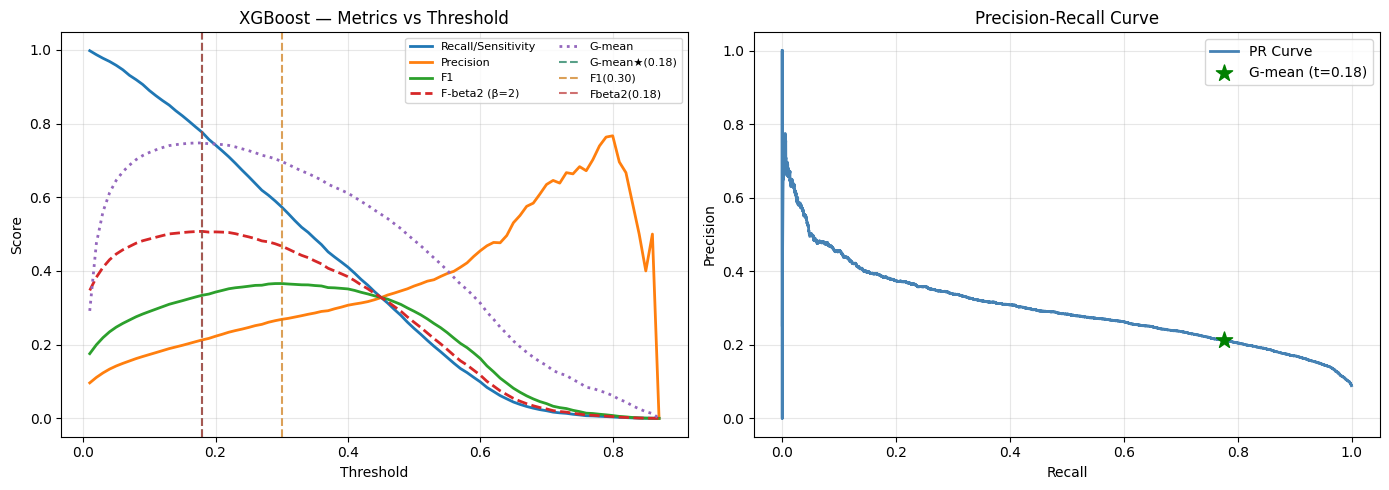

In [ ]:
ypr_xgb = fitted['XGBoost'].predict_proba(X_test)[:,1]

rows = []
for t in np.arange(0.01, 1.00, 0.01):
    yt_ = (ypr_xgb >= t).astype(int)
    if yt_.sum() == 0:
        continue
    tn, fp, fn, tp_ = confusion_matrix(y_test, yt_).ravel()
    rec  = tp_/(tp_+fn);  spec = tn/(tn+fp)
    prec = precision_score(y_test, yt_, zero_division=0)
    f1   = f1_score(y_test, yt_, zero_division=0)
    gm   = np.sqrt(rec*spec)
    fb2  = (1+4)*prec*rec / (4*prec+rec+1e-9)
    rows.append(dict(t=round(t,2), recall=rec, spec=spec,
                     prec=prec, f1=f1, gm=gm, fb2=fb2))

td   = pd.DataFrame(rows)
bgm  = td.loc[td['gm'].idxmax()]
bf1  = td.loc[td['f1'].idxmax()]
bfb2 = td.loc[td['fb2'].idxmax()]
cand = td[td['recall'] >= 0.80]
bbal = cand.loc[cand['prec'].idxmax()] if len(cand) else bgm
FINAL_T = float(bgm['t'])

print(f'Best G-mean  : thresh={bgm.t:.2f}  sens={bgm.recall:.4f}  '
      f'spec={bgm.spec:.4f}  gm={bgm.gm:.4f}')
print(f'Best F1      : thresh={bf1.t:.2f}  sens={bf1.recall:.4f}  f1={bf1.f1:.4f}')
print(f'Best Fbeta2  : thresh={bfb2.t:.2f}  sens={bfb2.recall:.4f}  fb2={bfb2.fb2:.4f}')
print(f'Sens>=0.80   : thresh={bbal.t:.2f}  sens={bbal.recall:.4f}  prec={bbal.prec:.4f}')
print(f'\n★ FINAL THRESHOLD (G-mean): {FINAL_T:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(td['t'], td['recall'], lw=2, label='Recall/Sensitivity')
ax.plot(td['t'], td['prec'],   lw=2, label='Precision')
ax.plot(td['t'], td['f1'],     lw=2, label='F1')
ax.plot(td['t'], td['fb2'],    lw=2, ls='--', label='F-beta2 (β=2)')
ax.plot(td['t'], td['gm'],     lw=2, ls=':',  label='G-mean')
for t, col, lbl in [
    (bgm.t,  '#208060', f'G-mean★({bgm.t:.2f})'),
    (bf1.t,  '#D08020', f'F1({bf1.t:.2f})'),
    (bfb2.t, '#C04040', f'Fbeta2({bfb2.t:.2f})')]:
    ax.axvline(t, color=col, ls='--', alpha=0.75, lw=1.5, label=lbl)
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('XGBoost — Metrics vs Threshold')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

prec_c, rec_c, _ = precision_recall_curve(y_test, ypr_xgb)
ax2 = axes[1]
ax2.plot(rec_c, prec_c, lw=2, color='steelblue', label='PR Curve')
ax2.scatter([bgm.recall], [bgm.prec], s=150, color='green',
            marker='*', zorder=5, label=f'G-mean (t={FINAL_T:.2f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(f'{OUT}/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Evaluation @ G-mean Threshold vs Default

── Default (0.50) ──
              precision    recall  f1-score   support

      No CVD       0.93      0.96      0.94     61980
         CVD       0.36      0.24      0.29      6051

    accuracy                           0.89     68031
   macro avg       0.64      0.60      0.62     68031
weighted avg       0.88      0.89      0.88     68031

── Optimal (0.18 — G-mean) ──
              precision    recall  f1-score   support

      No CVD       0.97      0.72      0.83     61980
         CVD       0.21      0.78      0.33      6051

    accuracy                           0.72     68031
   macro avg       0.59      0.75      0.58     68031
weighted avg       0.90      0.72      0.78     68031



,Sensitivity,Specificity,Precision,Gmean,F1,Accuracy
Threshold,,,,,,
Default (0.50),0.2439,0.9575,0.3590,0.4833,0.2905,0.8940
G-mean (0.18),0.7757,0.7199,0.2128,0.7473,0.3340,0.7248


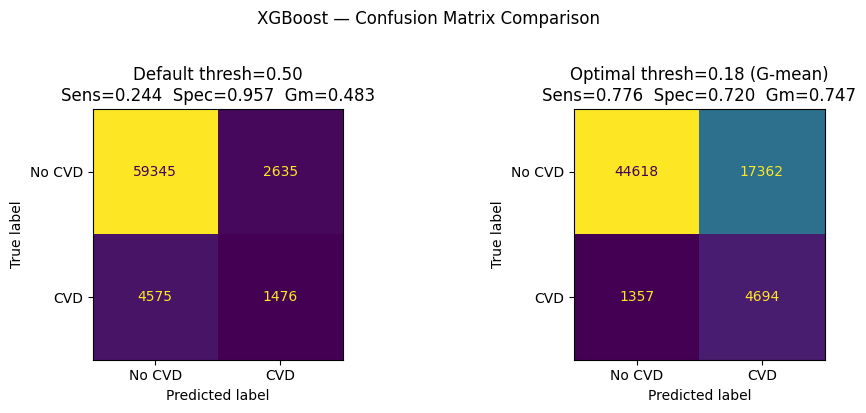

In [ ]:
y_opt = (ypr_xgb >= FINAL_T).astype(int)
y_def = (ypr_xgb >= 0.50).astype(int)

print(f'── Default (0.50) ──')
print(classification_report(y_test, y_def,
      target_names=['No CVD','CVD'], zero_division=0))
print(f'── Optimal ({FINAL_T:.2f} — G-mean) ──')
print(classification_report(y_test, y_opt,
      target_names=['No CVD','CVD'], zero_division=0))

# Comparison table
compare = []
for yp, label in [(y_def, f'Default (0.50)'), (y_opt, f'G-mean ({FINAL_T:.2f})')]:
    tn, fp, fn, tp_ = confusion_matrix(y_test, yp).ravel()
    sens = tp_/(tp_+fn); spec = tn/(tn+fp)
    prec = precision_score(y_test, yp, zero_division=0)
    compare.append(dict(
        Threshold=label,
        Sensitivity=round(sens,4), Specificity=round(spec,4),
        Precision=round(prec,4),
        Gmean=round(np.sqrt(sens*spec),4),
        F1=round(f1_score(y_test,yp,zero_division=0),4),
        Accuracy=round(accuracy_score(y_test,yp),4)
    ))
display(pd.DataFrame(compare).set_index('Threshold'))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, yp, title in zip(axes,
    [y_def, y_opt],
    [f'Default thresh=0.50', f'Optimal thresh={FINAL_T:.2f} (G-mean)']):
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['No CVD','CVD']).plot(
        ax=ax, values_format='d', colorbar=False)
    rec  = recall_score(y_test, yp, zero_division=0)
    spec = cm[0,0]/(cm[0,0]+cm[0,1])
    gm   = np.sqrt(rec*spec)
    ax.set_title(f'{title}\nSens={rec:.3f}  Spec={spec:.3f}  Gm={gm:.3f}')
plt.suptitle('XGBoost — Confusion Matrix Comparison', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(f'{OUT}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. ROC Curves & Model Comparison

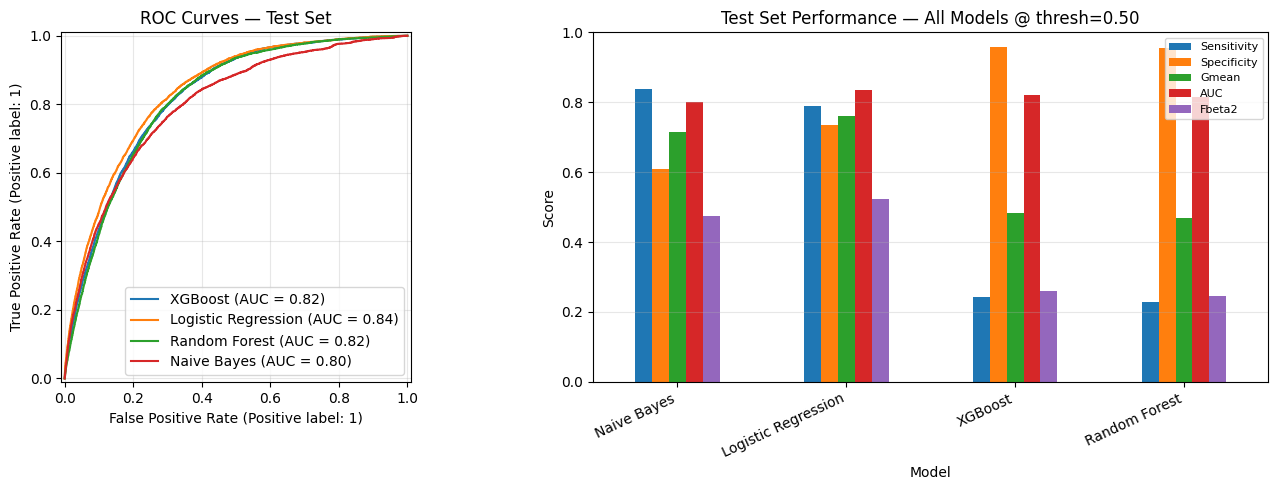

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, pipe in fitted.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.set_title('ROC Curves — Test Set')
ax.grid(alpha=0.3)

ax2 = axes[1]
plot_df = test_df.set_index('Model')[['Sensitivity','Specificity','Gmean','AUC','Fbeta2']]
plot_df.plot(kind='bar', ax=ax2)
ax2.set_title('Test Set Performance — All Models @ thresh=0.50')
ax2.set_ylabel('Score'); ax2.set_ylim(0, 1)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=25, ha='right')
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='upper right', fontsize=8)
plt.tight_layout()
fig.savefig(f'{OUT}/roc_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary NB3A

In [ ]:
print('='*65)
print('NB3A SUMMARY — Baseline Models')
print('='*65)
print(f'Dataset  : {len(dm):,} records  |  CVD rate: {dm["target"].mean()*100:.2f}%')
print(f'Features : {len(feat_cols)} cols')
print(f'Split    : 80/20 stratified')
print(f'Pipeline : Preprocessor → SMOTE → Model (ImbPipeline)')
print(f'Imbalance: SMOTE only (scale_pos_weight=1 for XGBoost)')
print()
print('── 10-fold CV (sorted by Recall) ──')
best_cv = cv_df.iloc[0]
print(f'  Best model : {best_cv["Model"]}')
print(f'    Recall   = {best_cv["recall_mean"]:.3f} ± {best_cv["recall_std"]:.3f}')
print(f'    ROC-AUC  = {best_cv["roc_auc_mean"]:.3f} ± {best_cv["roc_auc_std"]:.3f}')
print()
print(f'── XGBoost @ G-mean threshold = {FINAL_T:.2f} ──')
print(f'  Sensitivity : {bgm.recall:.4f}')
print(f'  Specificity : {bgm.spec:.4f}')
print(f'  G-mean      : {bgm.gm:.4f}')
print(f'  Precision   : {bgm.prec:.4f}')
print()
print('── Notes ──')
print('  [1] XGBoost scale_pos_weight=1 (not SPW) to avoid double correction with SMOTE')
print('  [2] GaussianNB results indicative only (Gaussian assumption violated for binary features)')
print()
print('→ Next: NB3B — Ablation study + Optuna tuning + SHAP analysis')
print(f'\n📁 Outputs: {OUT}/')
for f in sorted(os.listdir(OUT)):
    print(f'  {f}')

NB3A SUMMARY — Baseline Models
Dataset  : 340,154 records  |  CVD rate: 8.89%
Features : 50 cols
Split    : 80/20 stratified
Pipeline : Preprocessor → SMOTE → Model (ImbPipeline)
Imbalance: SMOTE only (scale_pos_weight=1 for XGBoost)

── 10-fold CV (sorted by Recall) ──
  Best model : Naive Bayes
    Recall   = 0.836 ± 0.006
    ROC-AUC  = 0.799 ± 0.005

── XGBoost @ G-mean threshold = 0.18 ──
  Sensitivity : 0.7757
  Specificity : 0.7199
  G-mean      : 0.7473
  Precision   : 0.2128

── Notes ──
  [1] XGBoost scale_pos_weight=1 (not SPW) to avoid double correction with SMOTE
  [2] GaussianNB results indicative only (Gaussian assumption violated for binary features)

→ Next: NB3B — Ablation study + Optuna tuning + SHAP analysis

📁 Outputs: /content/nb3a_outputs/
  confusion_matrix.png
  cv_results.csv
  roc_model_comparison.png
  test_results.csv
  threshold_tuning.png
